✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\41_dirfield_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\41_dirfield_3d.png


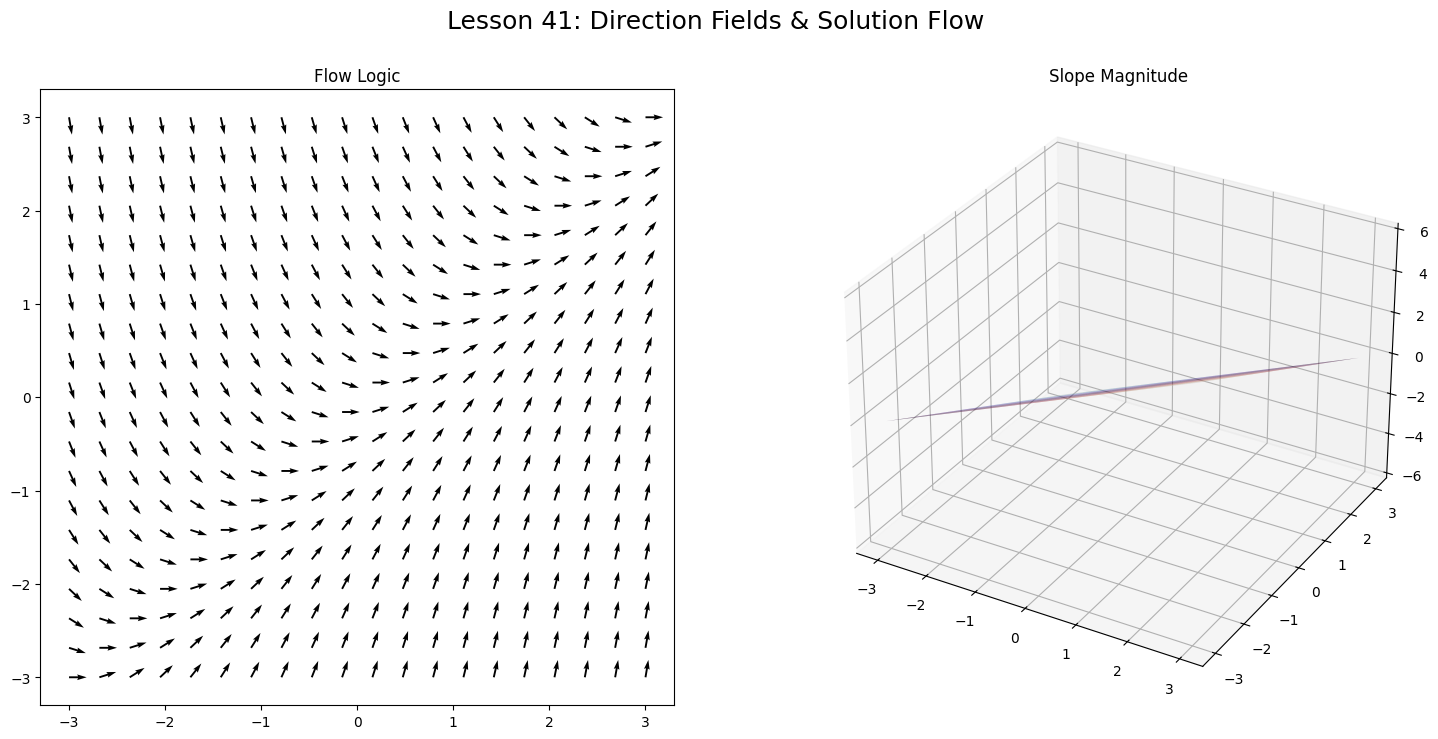

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_direction_field_master():
    # --- YOL AYARI ---
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Diferansiyel Denklem Tanımı: dy/dx = x - y
    def f(x, y):
        return x - y

    x = np.linspace(-3, 3, 20)
    y = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x, y)
    
    # Eğimleri hesapla
    dy = f(X, Y)
    dx = np.ones(dy.shape)
    
    # Okları normalize et (Görsel temizlik için)
    norm = np.sqrt(dx**2 + dy**2)
    dx /= norm
    dy /= norm

    # --- 📸 ASSET 1: 2D DIRECTION FIELD (41_dirfield_2d.png) ---
    fig2d, ax2d = plt.subplots(figsize=(10, 8))
    ax2d.quiver(X, Y, dx, dy, color='blue', alpha=0.6, pivot='mid')
    
    # Örnek bir çözüm eğrisi ekleyelim (y = x - 1 + C*e^-x)
    # Başlangıç noktası (0, 1) için: 1 = 0 - 1 + C => C = 2
    x_curve = np.linspace(-3, 3, 100)
    y_curve = x_curve - 1 + 2 * np.exp(-x_curve)
    ax2d.plot(x_curve, y_curve, 'r-', lw=3, label='Particular Solution (0,1)')
    
    ax2d.set_title(r"2D Direction Field: $\frac{dy}{dx} = x - y$", fontsize=14)
    ax2d.set_xlabel("x"); ax2d.set_ylabel("y")
    ax2d.set_ylim(-3, 3)
    ax2d.legend()
    ax2d.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '41_dirfield_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\41_dirfield_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: 3D SLOPE TERRAIN (41_dirfield_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    # Daha yoğun bir grid ile eğim şiddeti (Z)
    x_fine = np.linspace(-3, 3, 50)
    y_fine = np.linspace(-3, 3, 50)
    X_f, Y_f = np.meshgrid(x_fine, y_fine)
    Z_slope = f(X_f, Y_f)

    surf = ax3d.plot_surface(X_f, Y_f, Z_slope, cmap='twilight', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Slope Intensity Landscape", fontsize=14)
    ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('dy/dx')
    
    plt.savefig(os.path.join(asset_path, '41_dirfield_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\41_dirfield_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash = plt.figure(figsize=(18, 8))
    ax1 = fig_dash.add_subplot(121)
    ax1.quiver(X, Y, dx, dy)
    ax1.set_title("Flow Logic")
    
    ax2 = fig_dash.add_subplot(122, projection='3d')
    ax2.plot_surface(X_f, Y_f, Z_slope, cmap='twilight', alpha=0.6)
    ax2.set_title("Slope Magnitude")
    
    plt.suptitle("Lesson 41: Direction Fields & Solution Flow", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_direction_field_master()